In [8]:
# load Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [9]:
# load market datasets
DATA_DIR = Path("../data/raw")

files = [
    "SP500",
    "NASDAQ",
    "NIFTY50",
    "VIX",
    "DXY",
    "US10Y",
    "GOLD",
    "OIL",
    "BTC"
]

dfs = []

for asset in files:

    df = pd.read_parquet(DATA_DIR / f"{asset}.parquet")

    df = df[["Close","Volume"]]

    df.columns = [f"{asset}_close", f"{asset}_volume"]

    dfs.append(df)

market = pd.concat(dfs, axis=1)

market = market.sort_index().ffill()

market.head()

C:\Users\Shashwat Kumar\AppData\Local\Temp\ipykernel_7376\2264891674.py:28: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  market = pd.concat(dfs, axis=1)


,SP500_close,SP500_volume,NASDAQ_close,NASDAQ_volume,NIFTY50_close,NIFTY50_volume,VIX_close,VIX_volume,DXY_close,DXY_volume,US10Y_close,US10Y_volume,GOLD_close,GOLD_volume,OIL_close,OIL_volume,BTC_close,BTC_volume
Date,,,,,,,,,,,,,,,,,,
2000-01-03,1455.219971,9.318000e+08,4131.149902,1.510070e+09,NaN,NaN,24.209999,0.0,100.220001,0.0,6.548,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,1399.420044,1.009000e+09,3901.689941,1.511840e+09,NaN,NaN,27.010000,0.0,100.410004,0.0,6.485,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,1402.109985,1.085500e+09,3877.540039,1.735670e+09,NaN,NaN,26.410000,0.0,100.379997,0.0,6.599,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-06,1403.449951,1.092300e+09,3727.129883,1.598320e+09,NaN,NaN,25.730000,0.0,100.650002,0.0,6.549,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-07,1441.469971,1.225200e+09,3882.620117,1.634930e+09,NaN,NaN,21.719999,0.0,100.800003,0.0,6.504,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# load macro dataset

macro = pd.read_parquet("../data/raw/macro_data.parquet")

macro.index = pd.to_datetime(macro.index)

macro.head()

,US10Y,US2Y,FEDFUNDS,CPI,UNEMPLOYMENT,INDPRO,YIELD_SPREAD
2000-01-01,NaN,NaN,5.45,169.3,4.0,91.538,NaN
2000-01-03,6.58,6.38,5.45,169.3,4.0,91.538,0.20
2000-01-04,6.49,6.30,5.45,169.3,4.0,91.538,0.19
2000-01-05,6.62,6.38,5.45,169.3,4.0,91.538,0.24
2000-01-06,6.57,6.35,5.45,169.3,4.0,91.538,0.22


In [11]:
# merge datasets

data = market.join(macro, how="left")

data = data.sort_index().ffill()

data.head()

,SP500_close,SP500_volume,NASDAQ_close,NASDAQ_volume,NIFTY50_close,NIFTY50_volume,VIX_close,VIX_volume,DXY_close,DXY_volume,...,OIL_volume,BTC_close,BTC_volume,US10Y,US2Y,FEDFUNDS,CPI,UNEMPLOYMENT,INDPRO,YIELD_SPREAD
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,1455.219971,9.318000e+08,4131.149902,1.510070e+09,NaN,NaN,24.209999,0.0,100.220001,0.0,...,NaN,NaN,NaN,6.58,6.38,5.45,169.3,4.0,91.538,0.20
2000-01-04,1399.420044,1.009000e+09,3901.689941,1.511840e+09,NaN,NaN,27.010000,0.0,100.410004,0.0,...,NaN,NaN,NaN,6.49,6.30,5.45,169.3,4.0,91.538,0.19
2000-01-05,1402.109985,1.085500e+09,3877.540039,1.735670e+09,NaN,NaN,26.410000,0.0,100.379997,0.0,...,NaN,NaN,NaN,6.62,6.38,5.45,169.3,4.0,91.538,0.24
2000-01-06,1403.449951,1.092300e+09,3727.129883,1.598320e+09,NaN,NaN,25.730000,0.0,100.650002,0.0,...,NaN,NaN,NaN,6.57,6.35,5.45,169.3,4.0,91.538,0.22
2000-01-07,1441.469971,1.225200e+09,3882.620117,1.634930e+09,NaN,NaN,21.719999,0.0,100.800003,0.0,...,NaN,NaN,NaN,6.52,6.31,5.45,169.3,4.0,91.538,0.21


In [12]:
# dataset overview

data.shape

(7529, 25)

In [13]:
data.columns

Index(['SP500_close', 'SP500_volume', 'NASDAQ_close', 'NASDAQ_volume',
       'NIFTY50_close', 'NIFTY50_volume', 'VIX_close', 'VIX_volume',
       'DXY_close', 'DXY_volume', 'US10Y_close', 'US10Y_volume', 'GOLD_close',
       'GOLD_volume', 'OIL_close', 'OIL_volume', 'BTC_close', 'BTC_volume',
       'US10Y', 'US2Y', 'FEDFUNDS', 'CPI', 'UNEMPLOYMENT', 'INDPRO',
       'YIELD_SPREAD'],
      dtype='str')

In [14]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 7529 entries, 2000-01-03 to 2024-12-30
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SP500_close     7529 non-null   float64
 1   SP500_volume    7529 non-null   float64
 2   NASDAQ_close    7529 non-null   float64
 3   NASDAQ_volume   7529 non-null   float64
 4   NIFTY50_close   5563 non-null   float64
 5   NIFTY50_volume  5563 non-null   float64
 6   VIX_close       7529 non-null   float64
 7   VIX_volume      7529 non-null   float64
 8   DXY_close       7529 non-null   float64
 9   DXY_volume      7529 non-null   float64
 10  US10Y_close     7529 non-null   float64
 11  US10Y_volume    7529 non-null   float64
 12  GOLD_close      7359 non-null   float64
 13  GOLD_volume     7359 non-null   float64
 14  OIL_close       7364 non-null   float64
 15  OIL_volume      7364 non-null   float64
 16  BTC_close       3758 non-null   float64
 17  BTC_volume      3758 non-n

In [16]:
# date range

print(data.index.min(), data.index.max())

2000-01-03 00:00:00 2024-12-30 00:00:00


In [17]:
# save merged dataset

data.to_parquet("../data/processed/market_macro_dataset.parquet")

In [19]:
data.shape

(7529, 25)

In [20]:
# missing value diagnostics

data.isna().sum().sort_values(ascending=False)

BTC_close         3771
BTC_volume        3771
NIFTY50_close     1966
NIFTY50_volume    1966
GOLD_volume        170
GOLD_close         170
OIL_volume         165
OIL_close          165
SP500_close          0
DXY_close            0
VIX_volume           0
VIX_close            0
NASDAQ_volume        0
SP500_volume         0
NASDAQ_close         0
DXY_volume           0
US10Y_volume         0
US10Y_close          0
US10Y                0
US2Y                 0
FEDFUNDS             0
CPI                  0
UNEMPLOYMENT         0
INDPRO               0
YIELD_SPREAD         0
dtype: int64

<Axes: >

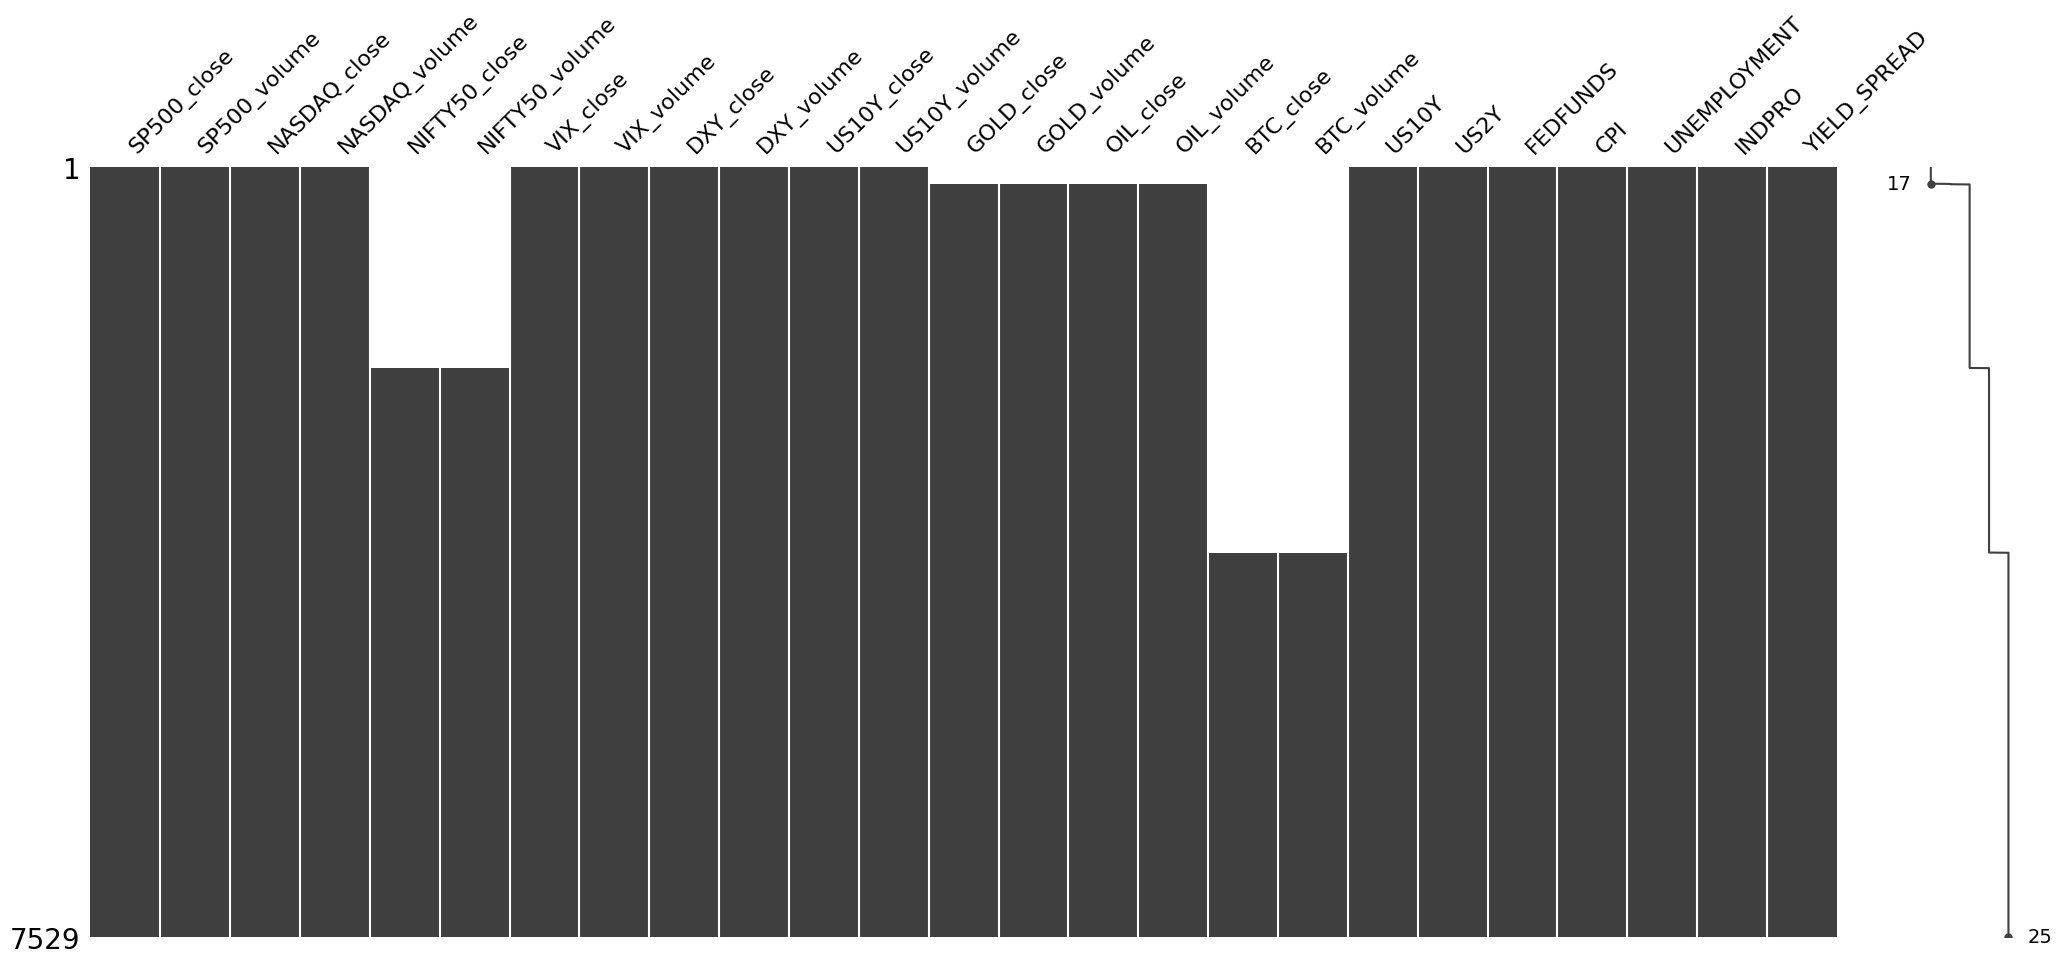

In [30]:
# missing value visualization
import missingno as msno
msno.matrix(data)

In [32]:
# duplicate timestamp check
data.index.duplicated().sum()

np.int64(0)

In [33]:
# weekday distribution
data.index.dayofweek.value_counts().sort_index()

Date
0    1278
1    1297
2    1298
3    1295
4    1287
5     537
6     537
Name: count, dtype: int64

In [35]:
# restrict dataset to business days
data = data[data.index.dayofweek < 5]

data.index.dayofweek.value_counts().sort_index()

Date
0    1278
1    1297
2    1298
3    1295
4    1287
Name: count, dtype: int64

In [36]:
data.shape

(6455, 25)

In [37]:
# macro missing values
data[["FEDFUNDS","CPI","UNEMPLOYMENT","INDPRO"]].isna().sum()

FEDFUNDS        0
CPI             0
UNEMPLOYMENT    0
INDPRO          0
dtype: int64

# Price Level Visualization

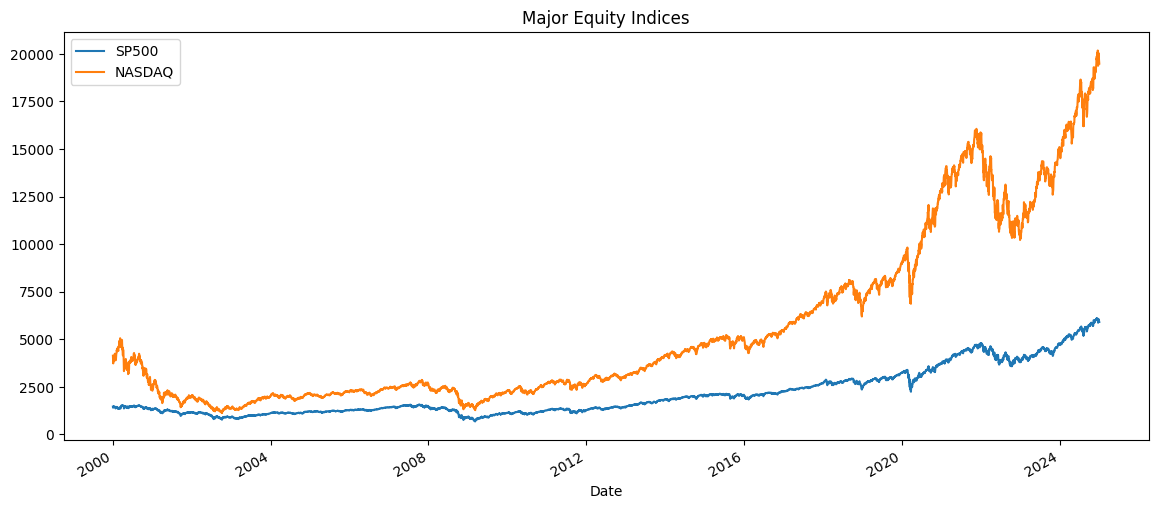

In [38]:
# equity indices

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

data["SP500_close"].plot(label="SP500")
data["NASDAQ_close"].plot(label="NASDAQ")

plt.legend()
plt.title("Major Equity Indices")
plt.show()

# Commoditites

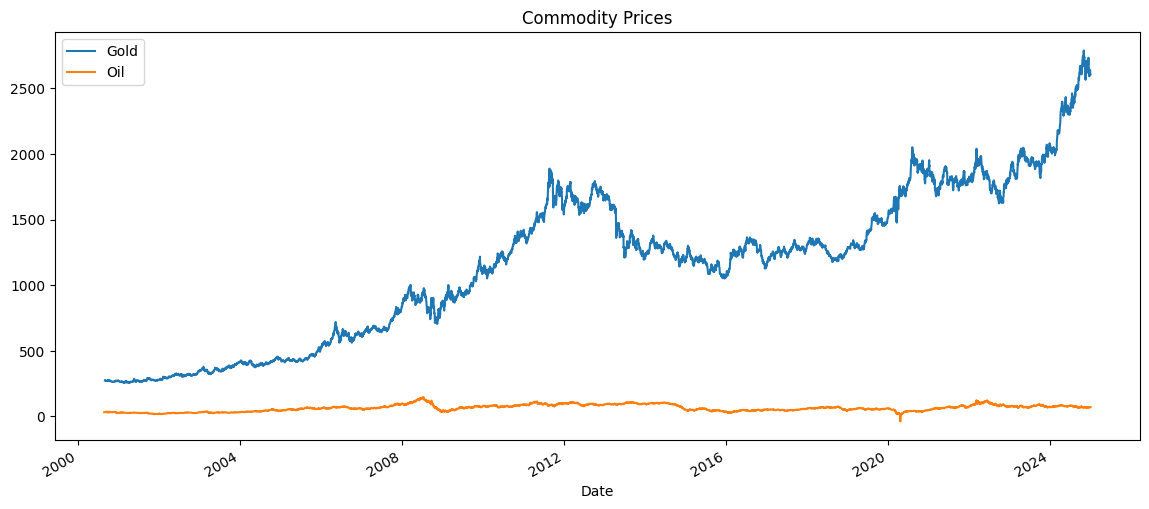

In [39]:
# commodities

plt.figure(figsize=(14,6))

data["GOLD_close"].plot(label="Gold")
data["OIL_close"].plot(label="Oil")

plt.legend()
plt.title("Commodity Prices")
plt.show()

# Volatility Index

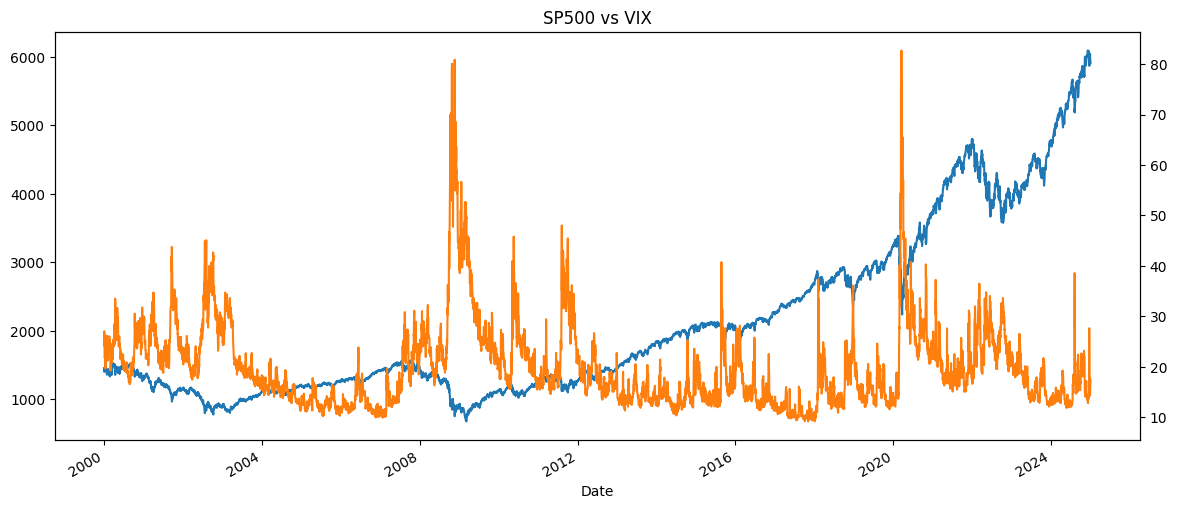

In [40]:
# vix vs equity

fig, ax = plt.subplots(figsize=(14,6))

data["SP500_close"].plot(ax=ax)
data["VIX_close"].plot(ax=ax, secondary_y=True)

plt.title("SP500 vs VIX")
plt.show()

# Log Returns

In [44]:
# extract close prices
prices = data.filter(like="_close")

# drop BTC so we keep full historical window
prices = prices.drop(columns=["BTC_close"])

# ensure sorted
prices = prices.sort_index()

# remove non-positive prices
prices = prices.where(prices > 0)

# compute log returns
returns = np.log(prices / prices.shift(1))

# drop rows where all returns are NaN
returns = returns.dropna(how="all")

returns.head()

,SP500_close,NASDAQ_close,NIFTY50_close,VIX_close,DXY_close,US10Y_close,GOLD_close,OIL_close
Date,,,,,,,,
2000-01-04,-0.039099,-0.057146,NaN,0.109441,0.001894,-0.009668,NaN,NaN
2000-01-05,0.001920,-0.006209,NaN,-0.022464,-0.000299,0.017426,NaN,NaN
2000-01-06,0.000955,-0.039562,NaN,-0.026085,0.002686,-0.007606,NaN,NaN
2000-01-07,0.026730,0.040872,NaN,-0.169424,0.001489,-0.006895,NaN,NaN
2000-01-10,0.011128,0.042125,NaN,-0.000461,0.001883,0.008268,NaN,NaN


In [45]:
# descriptive stats

returns.describe()

,SP500_close,NASDAQ_close,NIFTY50_close,VIX_close,DXY_close,US10Y_close,GOLD_close,OIL_close
count,6454.000000,6454.000000,4488.000000,6454.000000,6454.000000,6454.000000,6284.000000,6287.000000
mean,0.000217,0.000240,0.000370,-0.000051,0.000012,-0.000057,0.000359,0.000222
std,0.012075,0.015507,0.012936,0.070083,0.004816,0.023980,0.010718,0.025654
min,-0.127652,-0.131492,-0.139038,-0.350589,-0.027169,-0.347009,-0.098206,-0.282206
25%,-0.004560,-0.006115,-0.004939,-0.038583,-0.002669,-0.011061,-0.004567,-0.012111
50%,0.000359,0.000639,0.000050,-0.003620,0.000000,0.000000,0.000238,0.000303
75%,0.005709,0.007503,0.006200,0.032055,0.002704,0.010410,0.005963,0.012944
max,0.109572,0.132546,0.163343,0.768245,0.025237,0.404797,0.086432,0.319634


In [46]:
# tail statistics

from scipy.stats import skew, kurtosis

skew(returns["SP500_close"]), kurtosis(returns["SP500_close"])

(np.float64(-0.38977135507449306), np.float64(10.749582282266907))

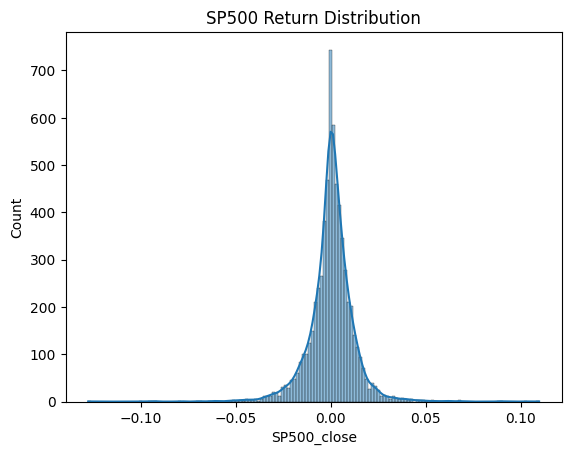

In [47]:
# distribution plot

import seaborn as sns

sns.histplot(returns["SP500_close"], bins=150, kde=True)

plt.title("SP500 Return Distribution")
plt.show()

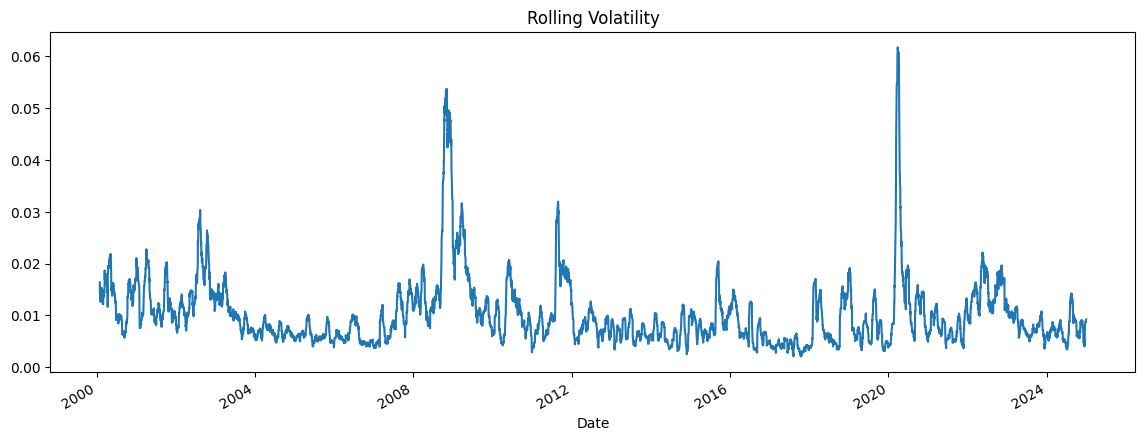

In [48]:
# rolling volatility

rolling_vol = returns["SP500_close"].rolling(20).std()

rolling_vol.plot(figsize=(14,5))

plt.title("Rolling Volatility")
plt.show()

Text(0.5, 1.0, 'Dot-Com Crash Volatility')

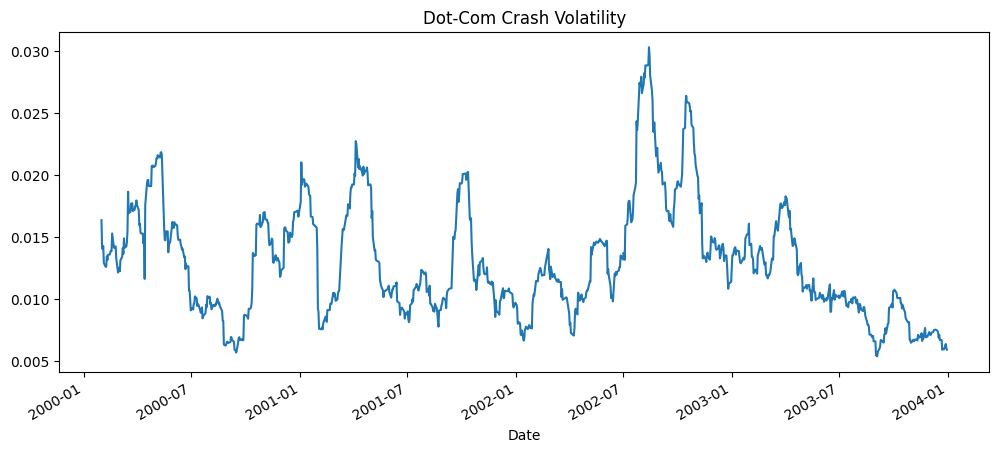

In [49]:
rolling_vol.loc["2000":"2003"].plot(figsize=(12,5))
plt.title("Dot-Com Crash Volatility")

Text(0.5, 1.0, '2008 Financial Crisis')

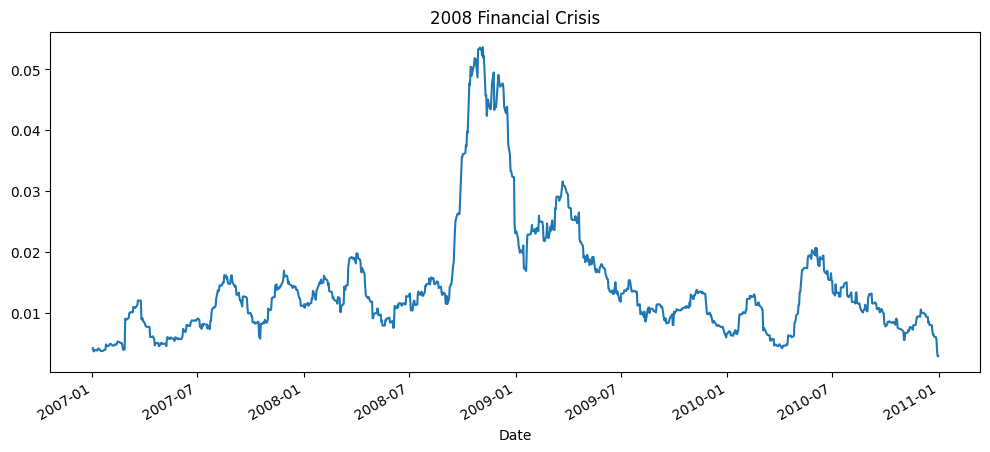

In [50]:
rolling_vol.loc["2007":"2010"].plot(figsize=(12,5))
plt.title("2008 Financial Crisis")

Text(0.5, 1.0, 'COVID Crash')

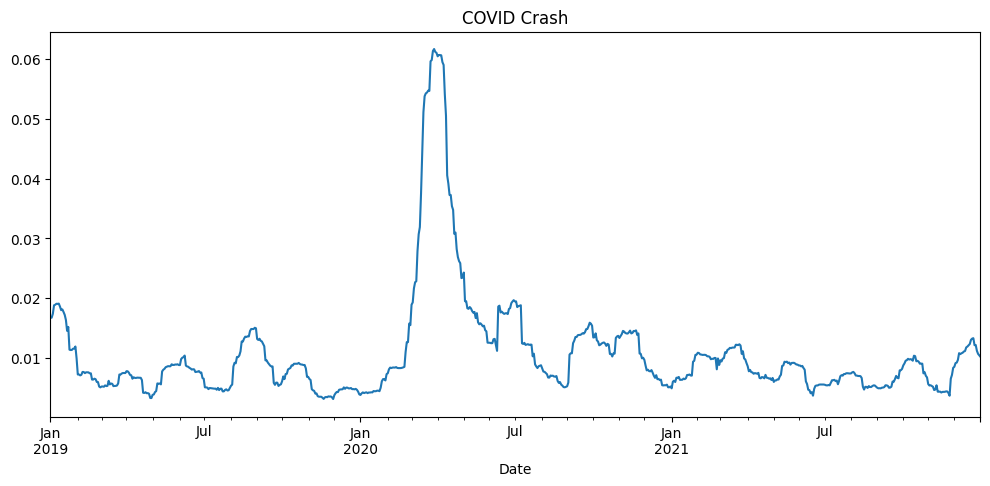

In [51]:
rolling_vol.loc["2019":"2021"].plot(figsize=(12,5))
plt.title("COVID Crash")

Text(0.5, 1.0, 'Inflation Regime')

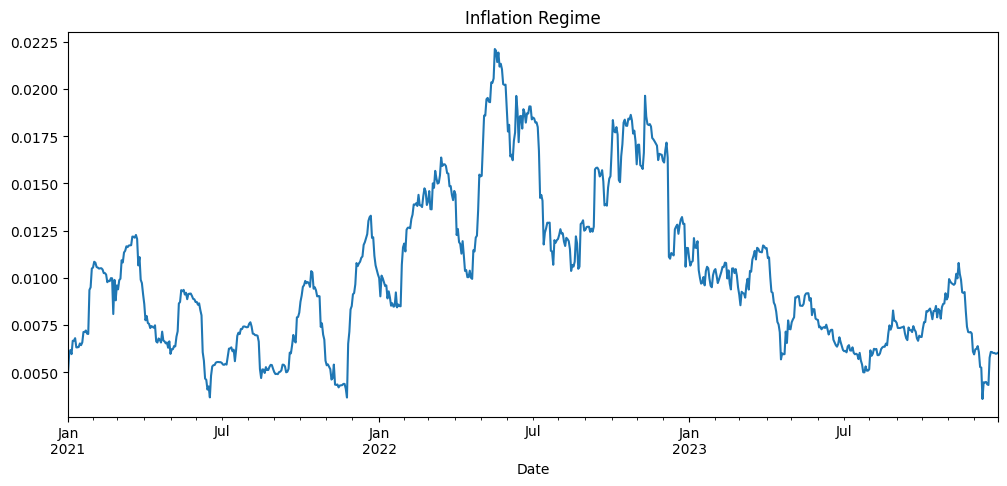

In [52]:
rolling_vol.loc["2021":"2023"].plot(figsize=(12,5))
plt.title("Inflation Regime")

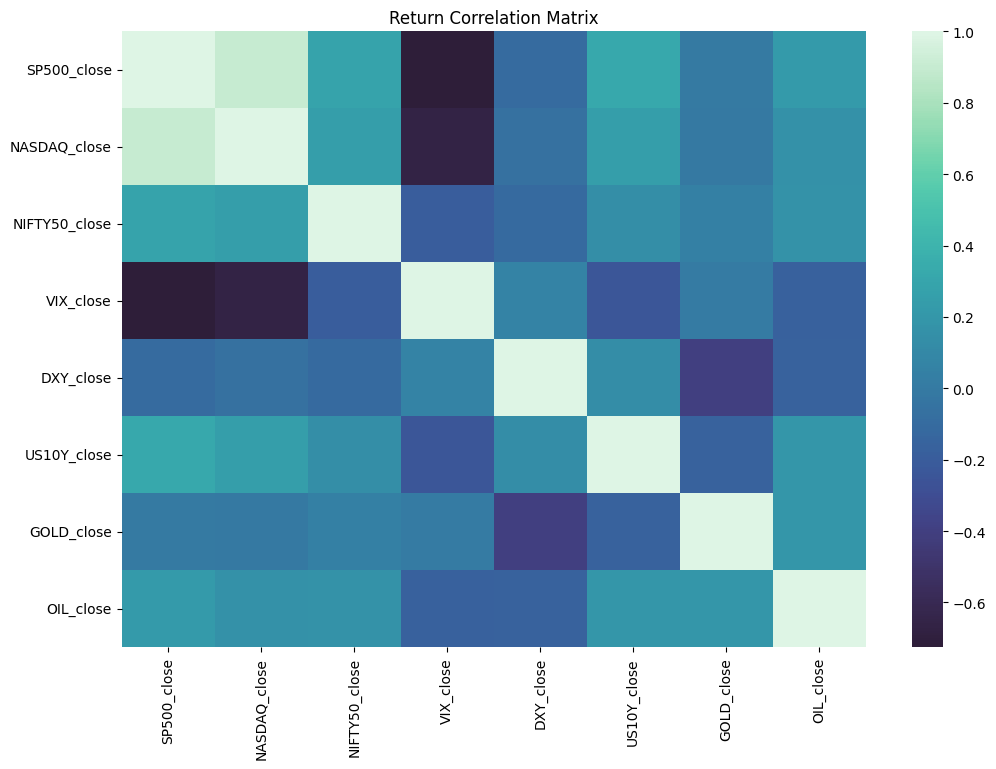

In [55]:
# correlation matrix

plt.figure(figsize=(12,8))

sns.heatmap(returns.corr(), cmap="mako", center=0)

plt.title("Return Correlation Matrix")
plt.show()

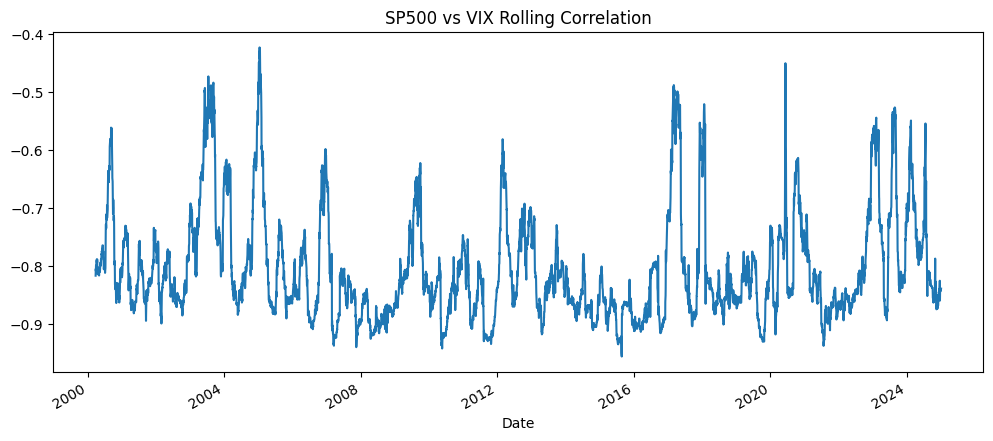

In [56]:
# equity vs volatility correlation

rolling_corr = returns["SP500_close"].rolling(60).corr(returns["VIX_close"])

rolling_corr.plot(figsize=(12,5))

plt.title("SP500 vs VIX Rolling Correlation")
plt.show()

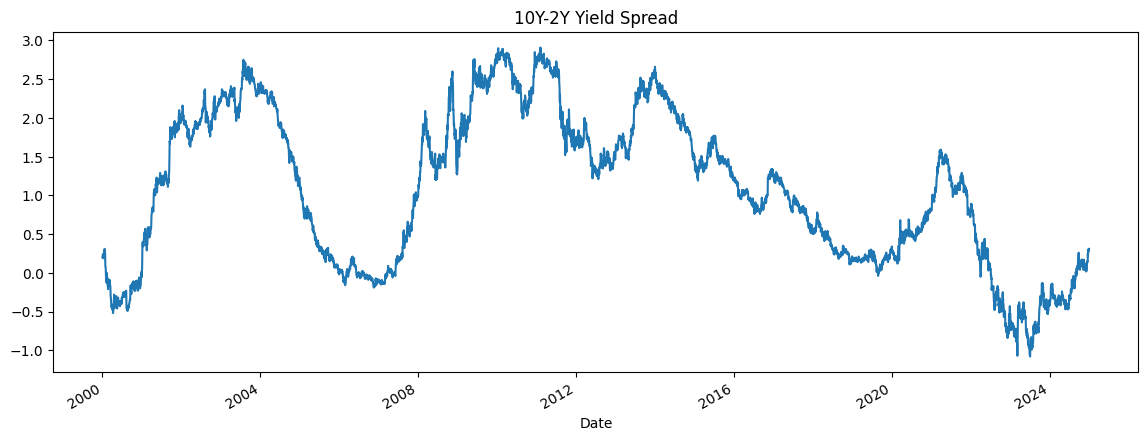

In [57]:
# yield spread

data["YIELD_SPREAD"].plot(figsize=(14,5))

plt.title("10Y-2Y Yield Spread")
plt.show()

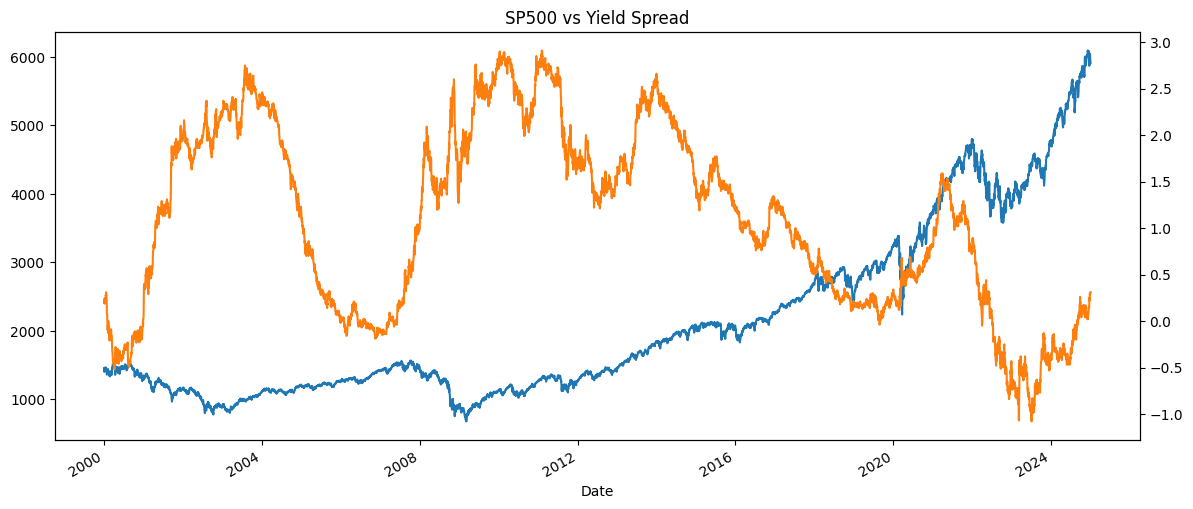

In [58]:
# macro interaction

fig, ax = plt.subplots(figsize=(14,6))

data["SP500_close"].plot(ax=ax)
data["YIELD_SPREAD"].plot(ax=ax, secondary_y=True)

plt.title("SP500 vs Yield Spread")
plt.show()

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

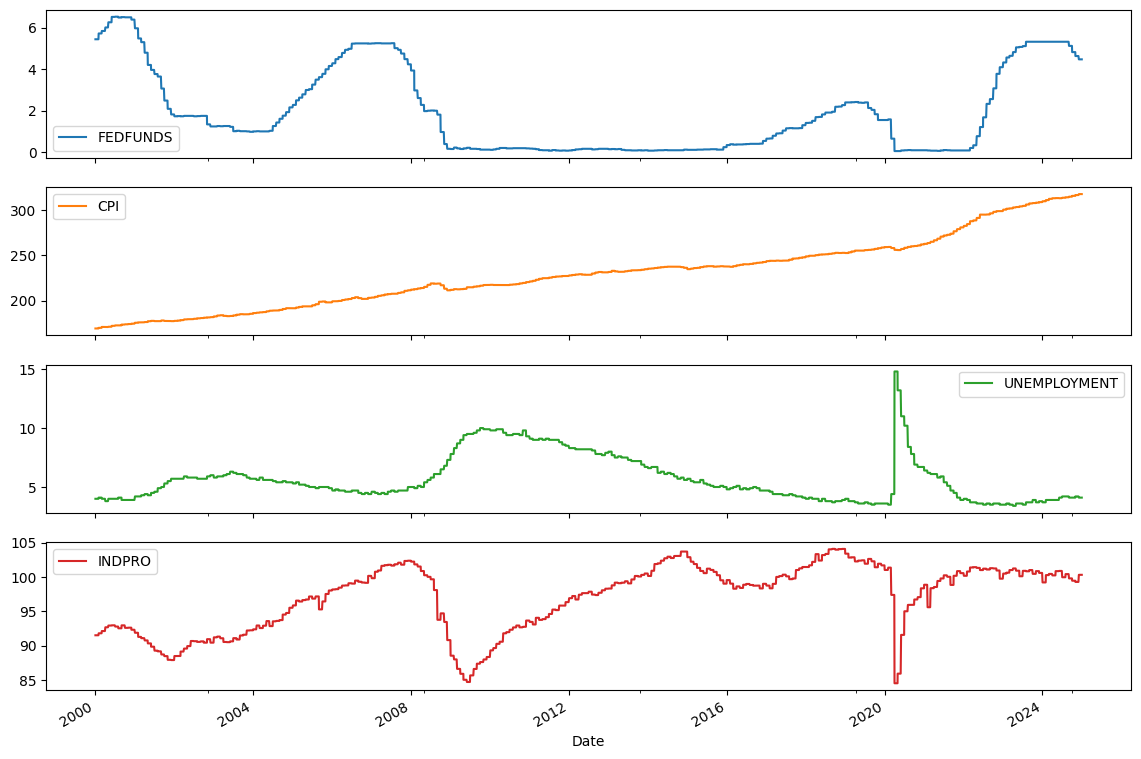

In [59]:
# macro variables

data[["FEDFUNDS","CPI","UNEMPLOYMENT","INDPRO"]].plot(
    subplots=True,
    figsize=(14,10)
)

In [60]:
# adf test

from statsmodels.tsa.stattools import adfuller

adfuller(returns["SP500_close"])

(np.float64(-17.7303153408123),
 np.float64(3.437227517371316e-30),
 22,
 6431,
 {'1%': np.float64(-3.4313672464764613),
  '5%': np.float64(-2.8619895349621585),
  '10%': np.float64(-2.5670092842156036)},
 np.float64(-38589.42568082537))

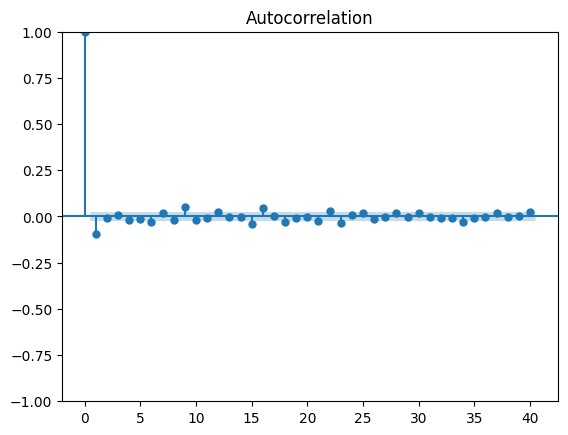

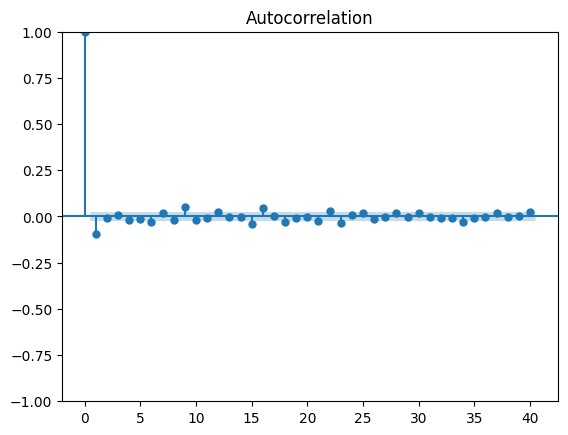

In [61]:
# autocorrelation

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(returns["SP500_close"], lags=40)

Text(0.5, 1.0, 'Volume Spikes')

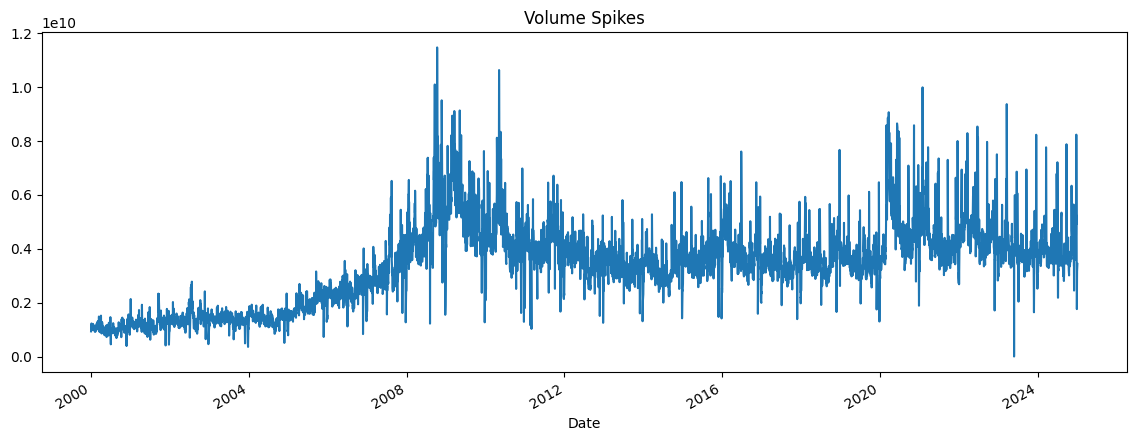

In [62]:
# liquidity spikes

data["SP500_volume"].plot(figsize=(14,5))

plt.title("Volume Spikes")

In [63]:
# extreme losses

np.percentile(returns["SP500_close"], 1)

np.float64(-0.034530222512631)

In [64]:
# save returns

returns.to_parquet("../data/processed/returns.parquet")

# PCA

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_returns = scaler.fit_transform(returns.dropna())

In [68]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(scaled_returns)

explained_var = pca.explained_variance_ratio_

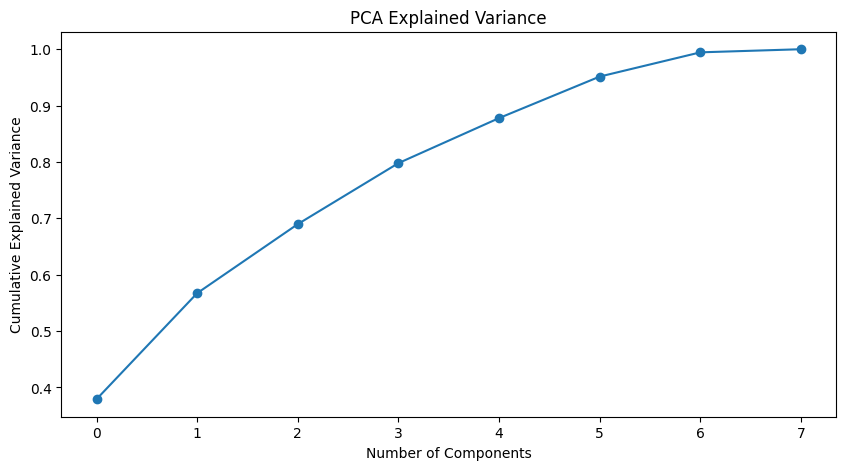

In [69]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

plt.plot(np.cumsum(explained_var), marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.show()

# Rolling Correlation Regime Analysis

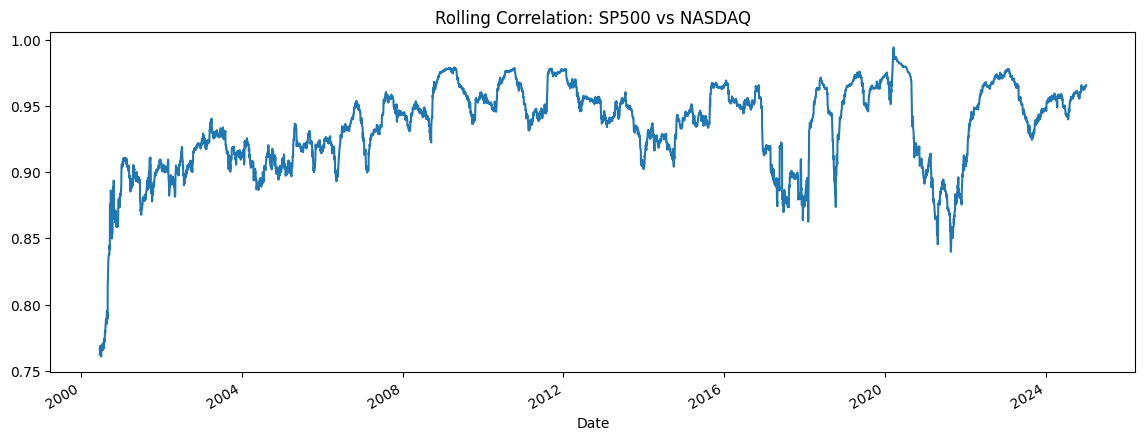

In [70]:
rolling_corr = returns["SP500_close"].rolling(120).corr(returns["NASDAQ_close"])

rolling_corr.plot(figsize=(14,5))

plt.title("Rolling Correlation: SP500 vs NASDAQ")
plt.show()

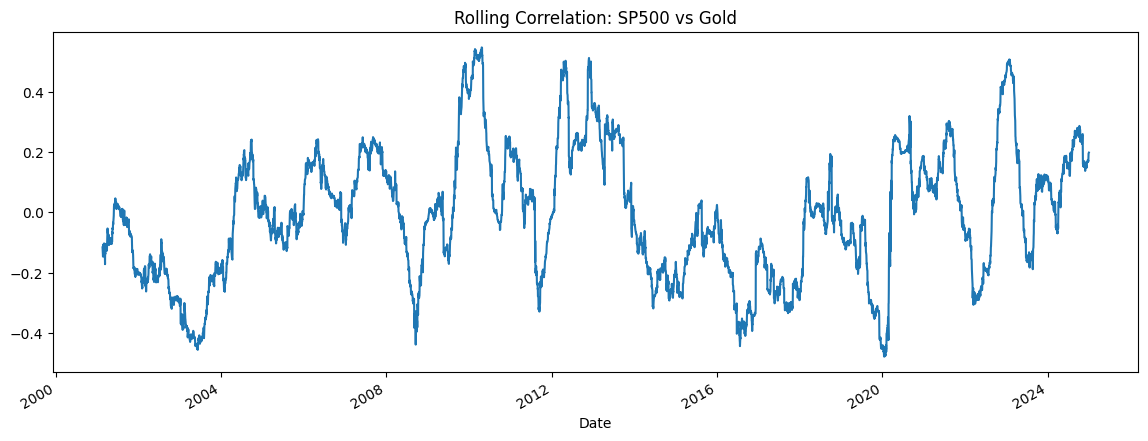

In [71]:
rolling_corr_gold = returns["SP500_close"].rolling(120).corr(returns["GOLD_close"])

rolling_corr_gold.plot(figsize=(14,5))

plt.title("Rolling Correlation: SP500 vs Gold")
plt.show()

# Volatility vs Return Regime Scatter

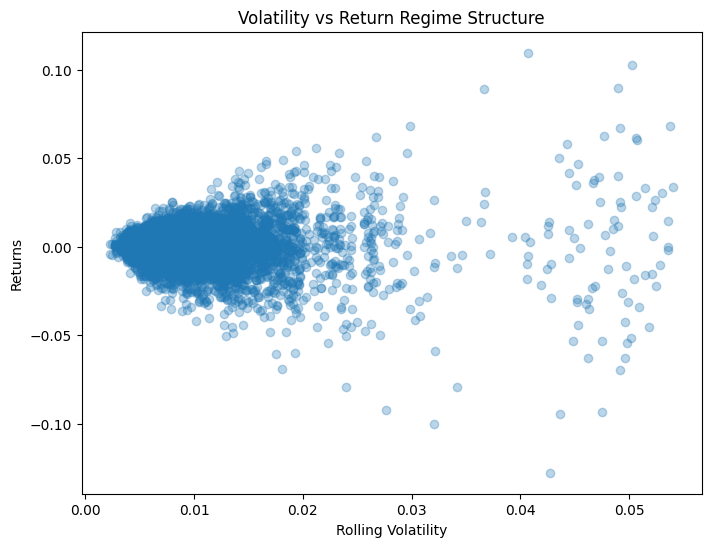

In [72]:
vol = returns["SP500_close"].rolling(30).std()
ret = returns["SP500_close"]

plt.figure(figsize=(8,6))

plt.scatter(vol, ret, alpha=0.3)

plt.xlabel("Rolling Volatility")
plt.ylabel("Returns")

plt.title("Volatility vs Return Regime Structure")

plt.show()

# VIX vs Market Return

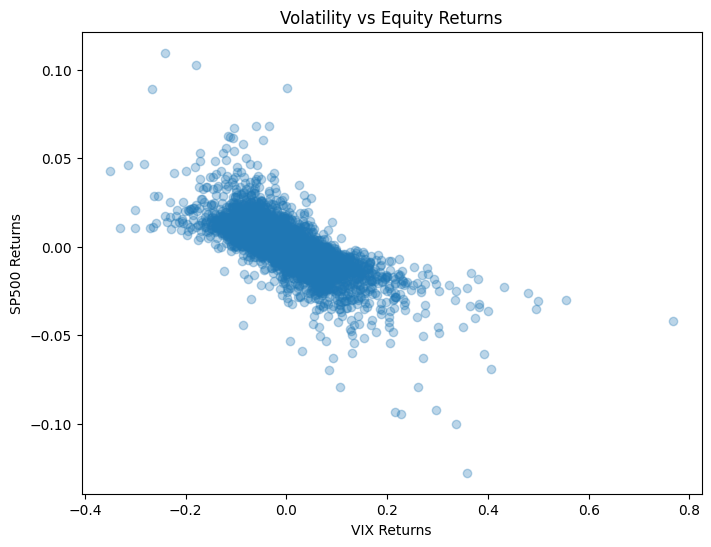

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(
    returns["VIX_close"],
    returns["SP500_close"],
    alpha=0.3
)

plt.xlabel("VIX Returns")
plt.ylabel("SP500 Returns")

plt.title("Volatility vs Equity Returns")

plt.show()